In [1]:
import pandas as pd
from lib.bck002 import *
from lib.cux001 import FactorEvaluate1

In [2]:
signal_data = pd.read_feather(
    '/workspace/worker/pj/Chrono/genuis/mizar/records/ricso2/rbb/temp/model/113001/5/rl/signal/equal_weight/7/rollrank2_signal/1002_test.feather')

In [3]:
period = 5

In [4]:
position_data = build_locked_signals(
    model_output=signal_data,
    base_position=999999,
    lot_per_signal=1,
    cooldown_bars=0,
    hold_bars=period,
    entry_resampling_win=period,
    date_col='trade_date' if 'trade_date' in signal_data.columns else None,
)

In [5]:
executed = position_data[position_data["signal_type"] == "open_exposure"].copy()

In [6]:
executed_signal = signal_data[["trade_time", "code", "nxt1_ret_5h"]].copy()
executed_signal = executed_signal.merge(
    executed[["trade_time", "code", "direction"]],
    on=["trade_time", "code"],
    how="left"
)

executed_signal["signal"] = executed_signal["direction"].fillna(0).astype(int)
executed_signal = executed_signal.drop(columns=["direction"])

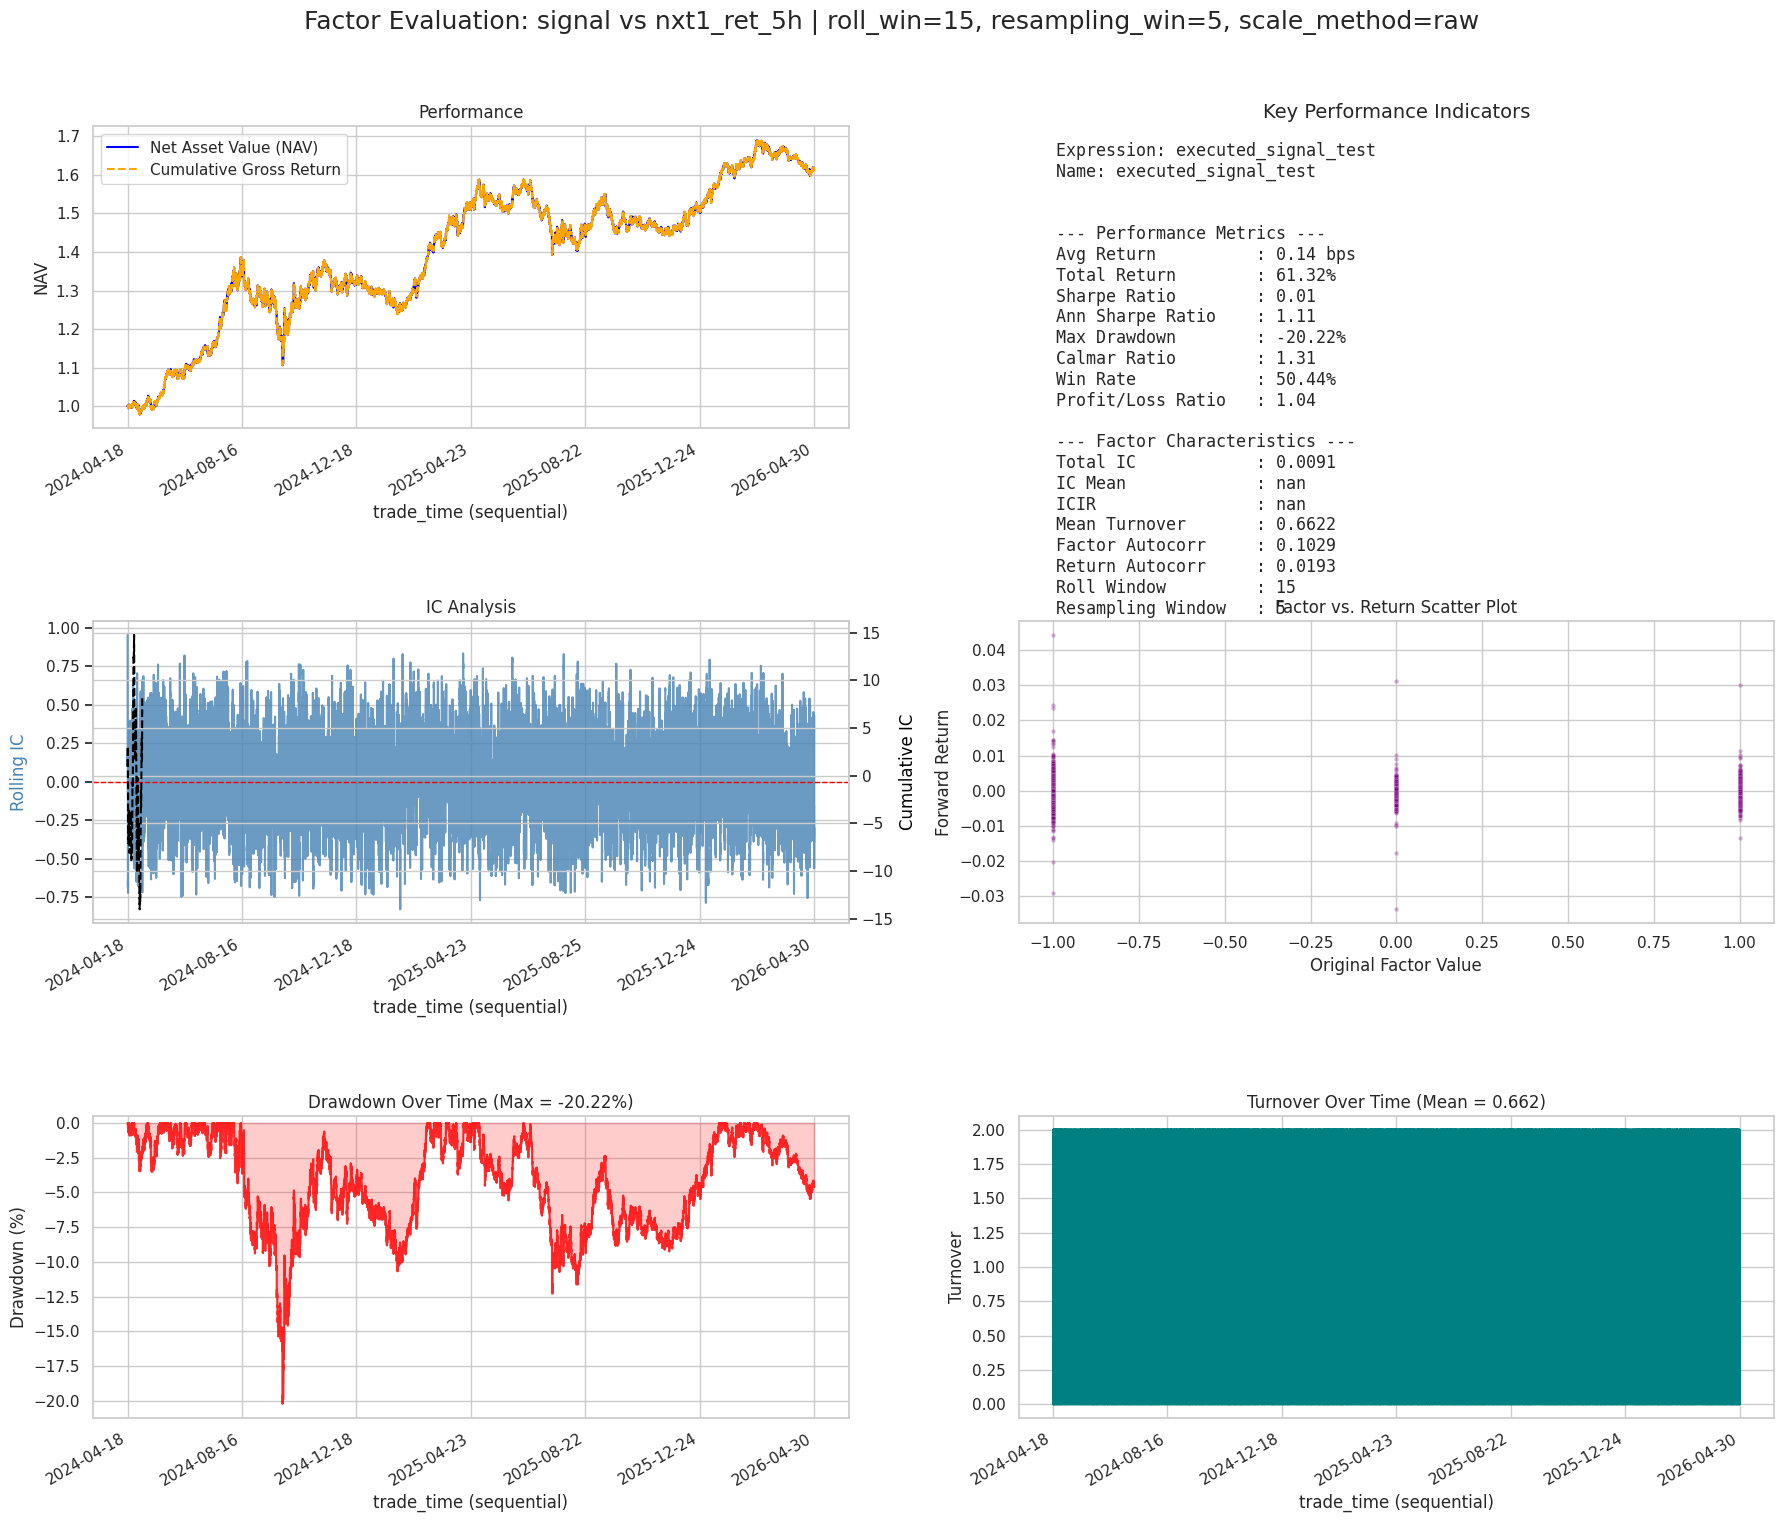

In [7]:
evaluate1 = FactorEvaluate1(
    factor_data=executed_signal,
    factor_name="signal",
    ret_name=f"nxt1_ret_{period}h",
    roll_win=15,
    fee=0.0,
    scale_method="raw",
    expression="executed_signal_test",
    resampling_win=period,
    name="executed_signal_test",
)
_ = evaluate1.run()
evaluate1.plot_results()

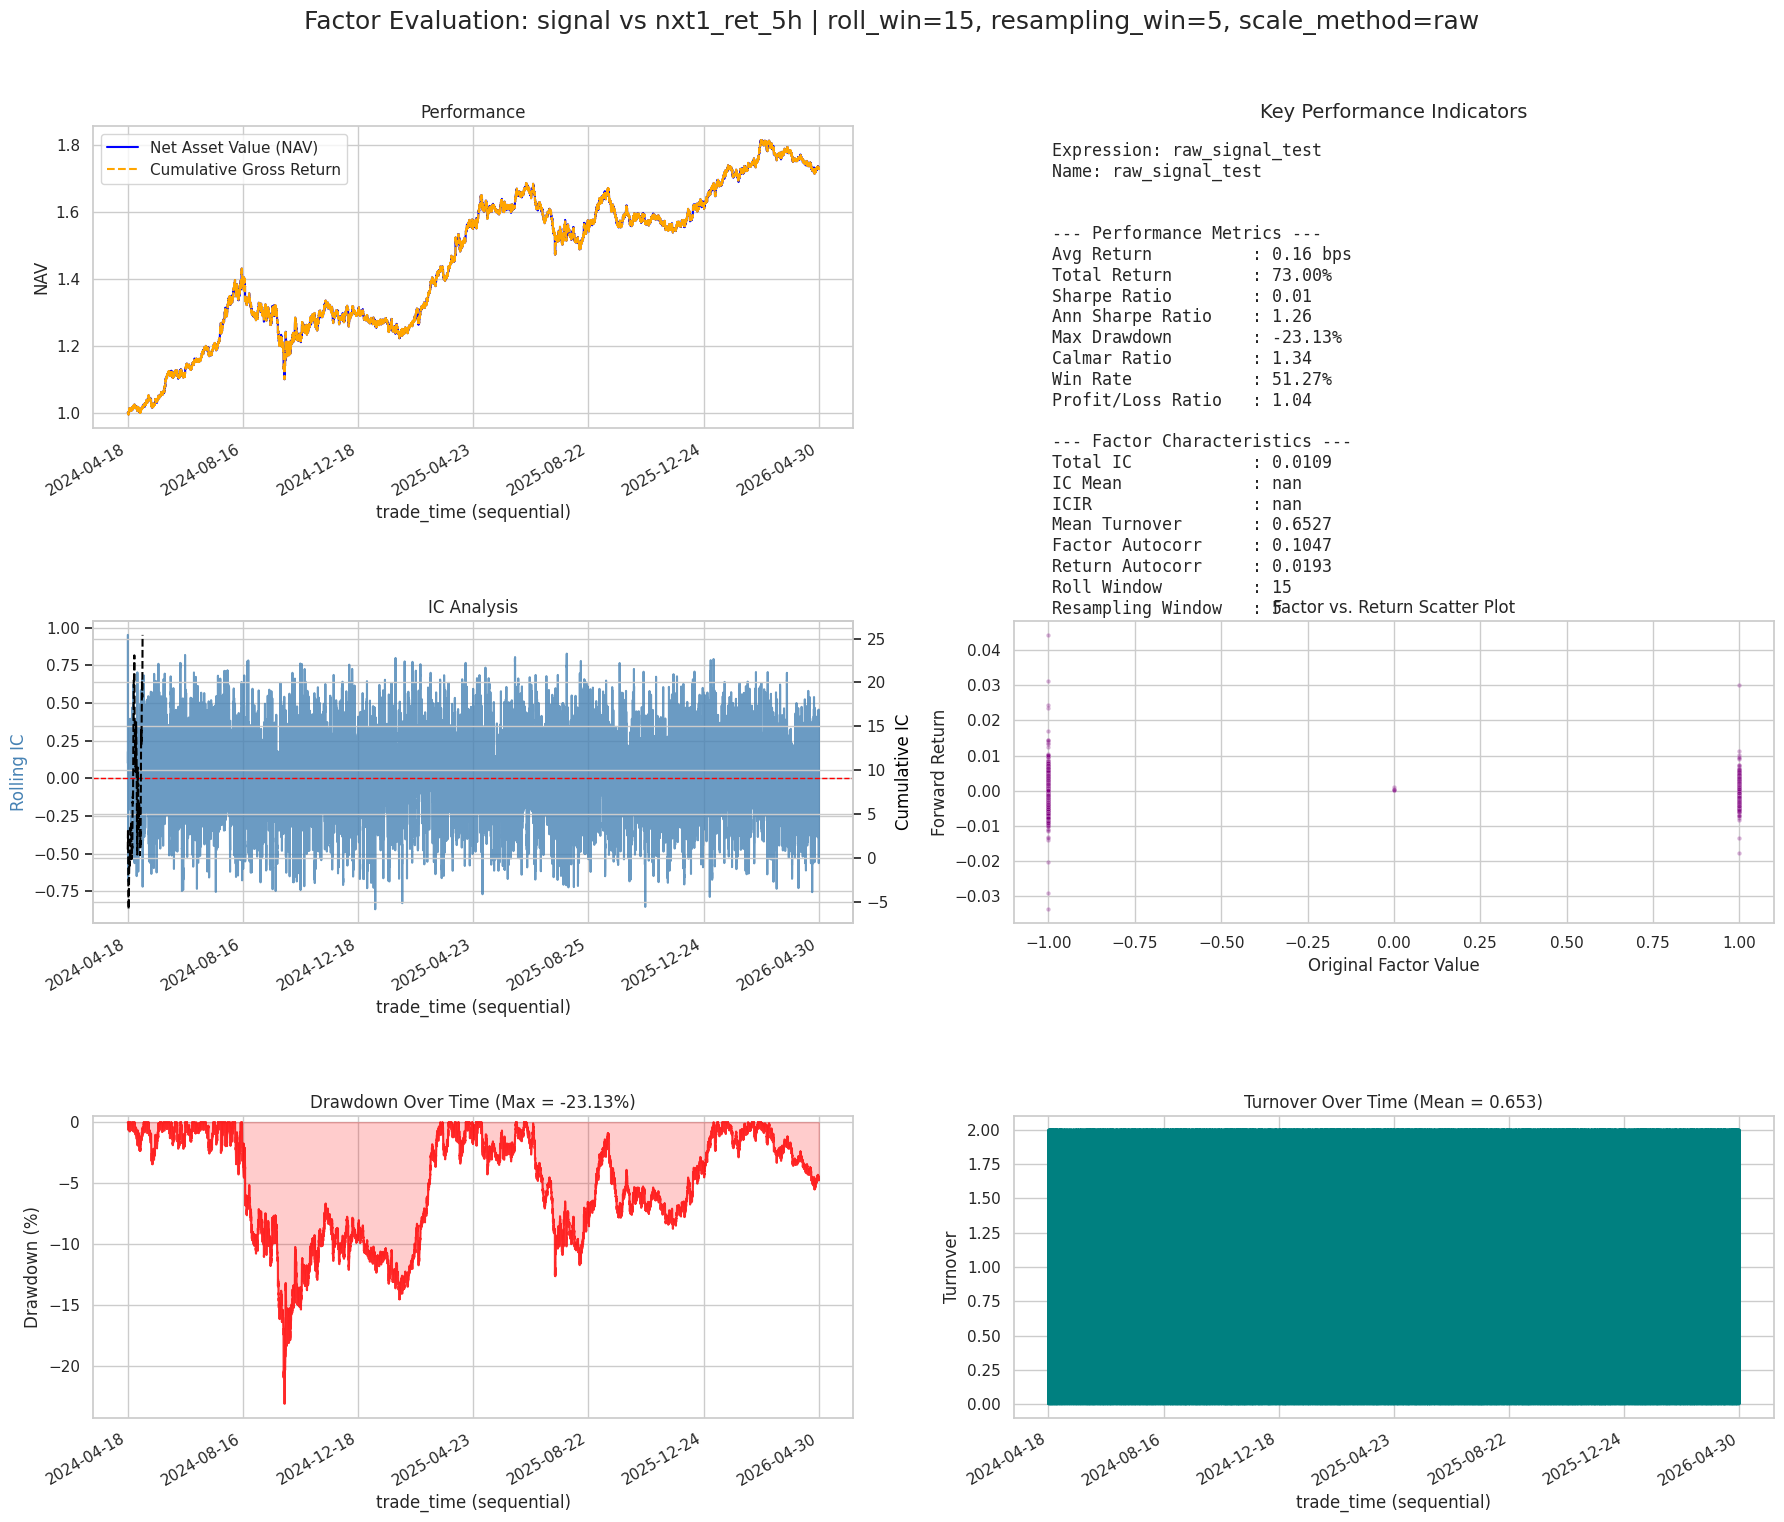

In [8]:
evaluate2 = FactorEvaluate1(
    factor_data=signal_data,
    factor_name="signal",
    ret_name=f"nxt1_ret_{period}h",
    roll_win=15,
    fee=0.0,
    scale_method="raw",
    expression="raw_signal_test",
    resampling_win=period,
    name="raw_signal_test",
)
_ = evaluate2.run()
evaluate2.plot_results()